# Difusion Optuna - ArtBench

## Setup

In [41]:
from __future__ import annotations

import sys
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
from torchvision.utils import make_grid
import torchvision.utils as vutils

In [42]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [43]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
EPOCHS = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## Dataset

In [ ]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:
    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = C:\Users\Jose\Mestrado\IAG_TP1
SCRIPTS_DIR    = C:\Users\Jose\Mestrado\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = C:\Users\Jose\Mestrado\IAG_TP1\ArtBench-10
TRAINING CSV   = C:\Users\Jose\Mestrado\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


In [45]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [46]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_dataset_completo = hf_ds["train"]

print("Número total de imagens de treino:", len(train_dataset_completo))
print("Colunas:", train_dataset_completo.column_names)

label_feature = train_dataset_completo.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

Dataset source: kaggle root='C:\Users\Jose\Mestrado\IAG_TP1\ArtBench-10'
Número total de imagens de treino: 50000
Colunas: ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [47]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p=0.5), # Inverte a pintura lateralmente
    #transforms.RandomRotation(degrees=10),  # Roda até 10 graus
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    '''inverte a normalização Normalize(0.5, 0.5, 0.5) que foi aplicada no transform. As imagens foram guardadas em [-1, 1] (necessário para o Tanh() do gerador), e esta função converte de volta para [0, 1] para poder visualizar com matplotlib.'''
    return (x * 0.5 + 0.5).clamp(0, 1)

In [48]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)

print("Número de IDs lidos do CSV:", len(train_ids_from_csv))
print("Primeiros 10 IDs:", train_ids_from_csv[:10])

Número de IDs lidos do CSV: 10000
Primeiros 10 IDs: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]


In [49]:
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [50]:
#train_subset = HFDatasetTorch(train_dataset_completo, transform=transform, indices=train_ids_from_csv)
train_full = HFDatasetTorch(train_dataset_completo, transform=transform)
train_loader = DataLoader(
    train_full,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Tamanho do subset:", len(train_full))
print("Número de batches:", len(train_loader))


Tamanho do subset: 50000
Número de batches: 782


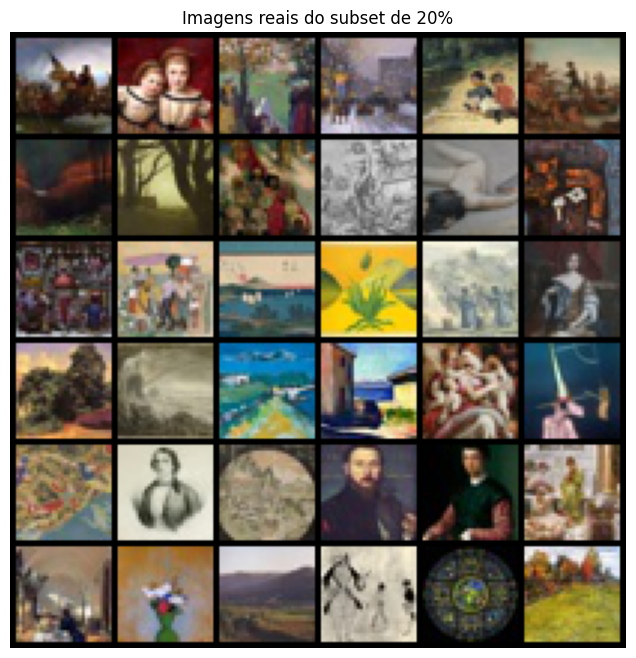

Exemplos de labels:
0: classe=romanticism 
1: classe=romanticism 
2: classe=post_impressionism 
3: classe=post_impressionism 
4: classe=realism 
5: classe=romanticism 
6: classe=surrealism 
7: classe=realism 
8: classe=post_impressionism 
9: classe=renaissance 
10: classe=post_impressionism 
11: classe=expressionism 


In [51]:
x, y, idx = next(iter(train_loader))

grid = make_grid(denorm(x[:36]), nrow=6, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Imagens reais do subset de 20%")
plt.show()

print("Exemplos de labels:")
for i in range(min(12, len(y))):
    print(f"{i}: classe={class_names[int(y[i])]} ")

## Difusion Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Parâmetros conforme o artigo
T = 1000  # Timesteps (podes usar 1000 se tiveres GPU forte)
beta_start = 0.0001
beta_end = 0.02

# 1. Linear Schedule para os Betas
betas = torch.linspace(beta_start, beta_end, T).to(DEVICE)

# 2. Derivação dos Alphas (conforme as fórmulas do link)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# 3. Cálculos para o processo Forward (q(x_t | x_0))
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# 4. Cálculos para o processo Backward (posterior variance)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def get_index_from_list(vals, t, x_shape):
    """Extrai o valor de 'vals' no índice 't' e ajusta o shape para as imagens."""
    batch_size = t.shape[0]
    out = vals.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

In [53]:
def forward_diffusion_sample(x_0, t, device="cpu"):
    """Recebe imagem limpa x_0 e retorna a versão ruidosa x_t."""
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x_0.shape)
    
    # Média + Variância
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
    + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, t):
        # t: [Batch]
        shape = t.shape
        sinusoid_inp = torch.outer(t, self.inv_freq)
        emb = torch.cat((sinusoid_inp.sin(), sinusoid_inp.cos()), dim=-1)
        return emb.view(*shape, self.dim)

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )
        

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch) 

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.residual_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        
        self.silu = nn.SiLU()

    def forward(self, x, t):
        res = self.residual_conv(x)
        
        h = self.silu(self.norm1(self.conv1(x)))
        time_emb = self.time_mlp(t)[:, :, None, None]
        h = h + time_emb
        h = self.norm2(self.conv2(h))
        return self.silu(h + res)



In [ ]:
class SimpleDiffusionUNet(nn.Module):
    def __init__(self, down_channels=(64, 128, 256), time_emb_dim=32):
        super().__init__()
        image_channels = 3
        up_channels = down_channels[::-1] 
        out_dim = 3

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )
        
        self.initial_conv = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) 
            for i in range(len(down_channels)-1)
        ])
        
        self.ups = nn.ModuleList([
            Block(up_channels[i] * 2, up_channels[i+1], time_emb_dim) 
            for i in range(len(up_channels)-1)
        ])
        
        self.final_conv = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
    
        t = self.time_mlp(t)
        x = self.initial_conv(x)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
            x = F.max_pool2d(x, 2)
        for up in self.ups:
    
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            res = residuals.pop()
            x = torch.cat((x, res), dim=1)    
            x = up(x, t)
            
        return self.final_conv(x)

In [ ]:
model_test = SimpleDiffusionUNet().to(DEVICE)
test_input = torch.randn(1, 3, 32, 32).to(DEVICE)
test_t = torch.randint(0, 300, (1,)).to(DEVICE)
output = model_test(test_input, test_t)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}") 

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 3, 32, 32])


In [ ]:
def get_loss(model, x_0, t, device):
    x_noisy, noise = forward_diffusion_sample(x_0, t, device)
    noise_pred = model(x_noisy, t)
    return F.mse_loss(noise, noise_pred)

In [58]:
%pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.


In [59]:
%pip install torchmetrics[image]
%pip install torch-fidelity

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [60]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

In [ ]:
from pathlib import Path

results_dir = Path(r"C:\Users\Jose\Mestrado\IAG_TP1\results")
seeds = [3, 17, 29, 58, 71, 89, 123, 256, 456, 512]

In [64]:
%pip install torchmetrics[image]

Note: you may need to restart the kernel to use updated packages.


In [63]:
%pip install diffusers

Note: you may need to restart the kernel to use updated packages.


In [65]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import optuna
from diffusers import DDPMScheduler

def objective(trial, fase):

    if fase == 1:
        lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
        beta_schedule = trial.suggest_categorical("beta_sched", ["linear", "squaredcos_cap_v2"])
        down_channels = (64, 128, 256)
        time_dim = 32
    
    elif fase == 2:
        lr, beta_schedule = 0.00046, "linear"
        base_ch = trial.suggest_categorical("base_ch", [32, 64, 128])
        down_channels = (base_ch, base_ch * 2, base_ch * 4)
        time_dim = trial.suggest_categorical("time_dim", [32, 64, 128])

    noise_scheduler = DDPMScheduler(
        num_train_timesteps=1000, 
        beta_schedule=beta_schedule,
        prediction_type="epsilon"
    )

    model = SimpleDiffusionUNet(
        down_channels=down_channels, 
        time_emb_dim=time_dim
    ).to(DEVICE)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


    model.train()
    for epoch in range(10):
        total_loss = 0
        for batch_idx, (x, _, _) in enumerate(train_loader):
            x = x.to(DEVICE)
            noise = torch.randn_like(x)
            timesteps = torch.randint(0, 1000, (x.shape[0],), device=DEVICE).long()

            noisy_images = noise_scheduler.add_noise(x, noise, timesteps)
            
            optimizer.zero_grad()

            noise_pred = model(noisy_images, timesteps)
            
            loss = F.mse_loss(noise_pred, noise)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        
        # Reportar para o Optuna (Pruning)
        trial.report(avg_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return avg_loss

study = optuna.create_study(direction="minimize")
study.optimize(lambda t: objective(t, fase=1), n_trials=20)

print("Melhores parâmetros encontrados:", study.best_params)

fase 2

In [ ]:

study = optuna.create_study(direction="minimize")
study.optimize(lambda t: objective(t, fase=2), n_trials=20)

print("Melhores parâmetros encontrados:", study.best_params)

[I 2026-04-24 00:39:29,207] A new study created in memory with name: no-name-937c9e8c-7be9-4b56-937b-a1824c31b10b
[I 2026-04-24 00:42:25,290] Trial 0 finished with value: 0.04066319504432428 and parameters: {'base_ch': 64, 'time_dim': 32}. Best is trial 0 with value: 0.04066319504432428.
[I 2026-04-24 00:45:20,016] Trial 1 finished with value: 0.041593173067945584 and parameters: {'base_ch': 64, 'time_dim': 32}. Best is trial 0 with value: 0.04066319504432428.
[I 2026-04-24 00:48:16,114] Trial 2 finished with value: 0.041590584744551 and parameters: {'base_ch': 64, 'time_dim': 64}. Best is trial 0 with value: 0.04066319504432428.
[I 2026-04-24 00:50:00,200] Trial 3 finished with value: 0.04203865056632051 and parameters: {'base_ch': 32, 'time_dim': 128}. Best is trial 0 with value: 0.04066319504432428.
[I 2026-04-24 00:52:54,987] Trial 4 finished with value: 0.039966473260977464 and parameters: {'base_ch': 64, 'time_dim': 64}. Best is trial 4 with value: 0.039966473260977464.
[I 2026-0

Melhores parâmetros encontrados: {'base_ch': 64, 'time_dim': 64}


In [ ]:
def objective_fase3(trial):

    lr = 0.000468
    beta_schedule = "linear"
    base_ch = 64
    time_dim = 64
    down_channels = (base_ch, base_ch * 2, base_ch * 4)
    

    wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    
    noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule=beta_schedule)
    
    model = SimpleDiffusionUNet(
        down_channels=down_channels, 
        time_emb_dim=time_dim
    ).to(DEVICE)
    

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    model.train()
    for epoch in range(20): 
        total_loss = 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            noise = torch.randn_like(x)
            timesteps = torch.randint(0, 1000, (x.shape[0],), device=DEVICE).long()
            
            noisy_images = noise_scheduler.add_noise(x, noise, timesteps)
            
            optimizer.zero_grad()
            noise_pred = model(noisy_images, timesteps)
            loss = F.mse_loss(noise_pred, noise)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        trial.report(avg_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return avg_loss


study_fase3 = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study_fase3.optimize(objective_fase3, n_trials=20)

print("Melhores parâmetros de Regularização:", study_fase3.best_params)

[I 2026-04-24 01:02:43,279] A new study created in memory with name: no-name-35714164-bbda-4bfa-89d1-680a1c4e3148
[I 2026-04-24 01:08:32,799] Trial 0 finished with value: 0.0380977434195151 and parameters: {'weight_decay': 7.368396991666456e-06}. Best is trial 0 with value: 0.0380977434195151.
[I 2026-04-24 01:14:21,803] Trial 1 finished with value: 0.03887098484263299 and parameters: {'weight_decay': 2.271043763155328e-05}. Best is trial 0 with value: 0.0380977434195151.
[I 2026-04-24 01:20:11,363] Trial 2 finished with value: 0.037861655519646445 and parameters: {'weight_decay': 3.231627576734921e-05}. Best is trial 2 with value: 0.037861655519646445.
[I 2026-04-24 01:26:00,939] Trial 3 finished with value: 0.03876651918432515 and parameters: {'weight_decay': 1.1333796095318895e-06}. Best is trial 2 with value: 0.037861655519646445.
[I 2026-04-24 01:31:50,717] Trial 4 finished with value: 0.03762706795078554 and parameters: {'weight_decay': 3.1473828887213996e-06}. Best is trial 4 wi

Melhores parâmetros de Regularização: {'weight_decay': 3.1473828887213996e-06}


In [ ]:
def train_final_diffusion_model(train_loader, epochs=100):
 
    LR = 0.0004685
    BETA_SCHED = "linear"
    BASE_CH = 64
    TIME_DIM = 64
    WEIGHT_DECAY = 3.147e-06
    T = 1000 
    patience=10

    noise_scheduler = DDPMScheduler(num_train_timesteps=T, beta_schedule=BETA_SCHED)
    model = SimpleDiffusionUNet(
        down_channels=(BASE_CH, BASE_CH*2, BASE_CH*4), 
        time_emb_dim=TIME_DIM
    ).to(DEVICE)
    
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=LR, 
        weight_decay=WEIGHT_DECAY
    )

    history = {"iteration_losses": [], "epoch_losses": []}

    best_loss = float('inf')
    epochs_without_improvement = 0
    best_model_state = None

    model.train()
    print(f"Iniciando Treino Final com Early Stopping (paciência: {patience})...")

    for epoch in range(epochs):
        progress_bar = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs}")
        epoch_loss = 0
        
        for batch in progress_bar:
            x = batch[0].to(DEVICE)
            noise = torch.randn_like(x)
            timesteps = torch.randint(0, T, (x.shape[0],), device=DEVICE).long()

            noisy_x = noise_scheduler.add_noise(x, noise, timesteps)

            optimizer.zero_grad()
            noise_pred = model(noisy_x, timesteps)
            loss = F.mse_loss(noise_pred, noise)
            
            loss.backward()
            optimizer.step()
            
            current_loss = loss.item()
            history["iteration_losses"].append(current_loss)
            epoch_loss += current_loss
            progress_bar.set_postfix({"loss": f"{current_loss:.4f}"})
            

        avg_epoch_loss = epoch_loss / len(train_loader)
        history["epoch_losses"].append(avg_epoch_loss)
        
        print(f"Época {epoch+1} terminada. Loss Média: {avg_epoch_loss:.6f}")


        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
        else:
            epochs_without_improvement += 1
            print(f"Sem melhoria na Loss (Paciência: {epochs_without_improvement}/{patience})")

        if epochs_without_improvement >= patience:
            print(f"\nEarly Stopping ativado! O treino parou na época {epoch+1}.")
            model.load_state_dict(best_model_state)
            break
    
    return model, history

In [ ]:
@torch.no_grad()
def evaluate_diffusion_quick_test(seeds_list, results_path, target_samples=5000, batch_size=64):
    model = SimpleDiffusionUNet(down_channels=(64, 128, 256), time_emb_dim=64).to(DEVICE)
    noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
    all_seed_results = []
    fid_metric = FrechetInceptionDistance(feature=2048).to(DEVICE)
    kid_metric = KernelInceptionDistance(subset_size=100).to(DEVICE)
    for seed in seeds_list:
        model_file = Path(results_path) / f"diffusion_optuna_final_full_seed_{seed}.pth"
        model.load_state_dict(torch.load(model_file, map_location=DEVICE))
        model.eval()

        fid_metric.reset()
        kid_metric.reset()
        
        # 1. Carregar 5000 imagens REAIS (necessário para estabilidade do FID)
        print(f"-> Seed {seed}: A carregar 5000 imagens reais...")
        real_count = 0
        for x, *_ in train_loader:
            real_uint8 = ((x.to(DEVICE) * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8)
            fid_metric.update(real_uint8, real=True)
            kid_metric.update(real_uint8, real=True)
            real_count += x.size(0)
            if real_count >= 5000: break

        # 2. Gerar 1000 imagens FALSAS
        samples_collected = 0
        pbar = tqdm(total=target_samples, desc=f"Seed {seed} - Gerando {target_samples} fakes")
        while samples_collected < target_samples:
            current_batch = min(batch_size, target_samples - samples_collected)
            img = torch.randn((current_batch, 3, 32, 32), device=DEVICE)
            for t in reversed(range(1000)):
                t_batch = torch.full((current_batch,), t, device=DEVICE).long()
                img = noise_scheduler.step(model(img, t_batch), t, img).prev_sample
            
            img_uint8 = ((img.clamp(-1, 1) * 0.5 + 0.5) * 255).to(torch.uint8)
            fid_metric.update(img_uint8, real=False)
            kid_metric.update(img_uint8, real=False)
            samples_collected += current_batch
            pbar.update(current_batch)
        pbar.close()

        # 3. Computar métricas finais
        fid_val = fid_metric.compute().item()
        kid_mean, kid_std = kid_metric.compute()
        all_seed_results.append({
            "seed": seed, 
            "fid": fid_val, 
            "kid": kid_mean.item(), 
            "kid_std": kid_std.item()
        })
        
    return all_seed_results

In [75]:
import json


A TREINAR A SEED 456...
Iniciando Treino Final com Early Stopping (paciência: 10)...


Época 1/100: 100%|██████████| 782/782 [01:39<00:00,  7.89it/s, loss=0.0823]


Época 1 terminada. Loss Média: 0.062250


Época 2/100: 100%|██████████| 782/782 [01:37<00:00,  8.03it/s, loss=0.1211]


Época 2 terminada. Loss Média: 0.042165


...

Época 53 terminada. Loss Média: 0.034084
Sem melhoria na Loss (Paciência: 8/10)


Época 54/100: 100%|██████████| 782/782 [01:28<00:00,  8.82it/s, loss=0.0295]


Época 54 terminada. Loss Média: 0.034404
Sem melhoria na Loss (Paciência: 9/10)


Época 55/100: 100%|██████████| 782/782 [01:29<00:00,  8.75it/s, loss=0.0236]


Época 55 terminada. Loss Média: 0.034569
Sem melhoria na Loss (Paciência: 10/10)

Early Stopping ativado! O treino parou na época 55.


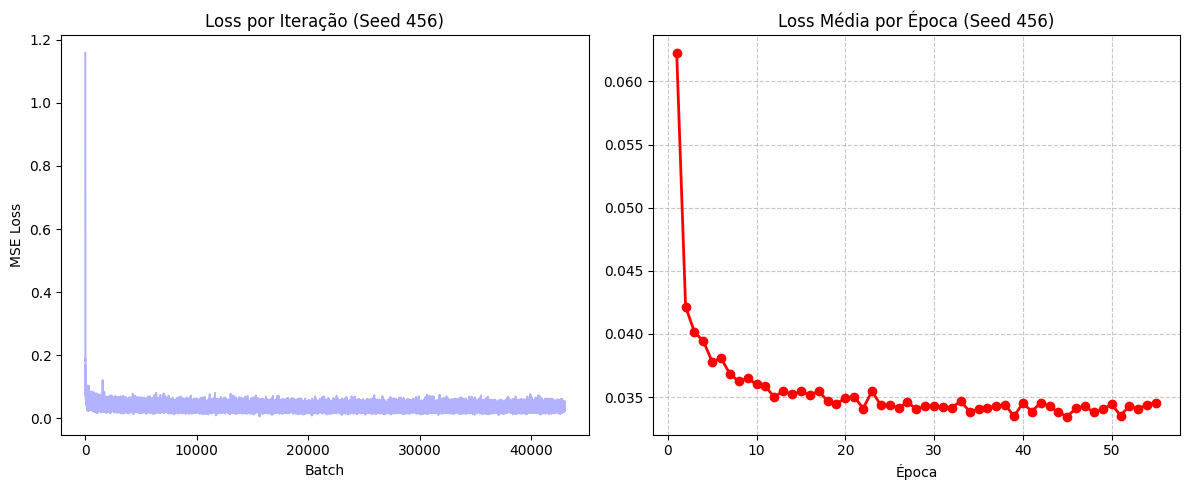

Treino e Gráficos da Seed 456 concluídos.

A TREINAR A SEED 512...
Iniciando Treino Final com Early Stopping (paciência: 10)...


Época 1/100: 100%|██████████| 782/782 [01:28<00:00,  8.83it/s, loss=0.0504]


Época 1 terminada. Loss Média: 0.059760


Época 2/100: 100%|██████████| 782/782 [01:28<00:00,  8.85it/s, loss=0.0249]


Época 2 terminada. Loss Média: 0.041603


...

Época 50 terminada. Loss Média: 0.034013
Sem melhoria na Loss (Paciência: 8/10)


Época 51/100: 100%|██████████| 782/782 [01:29<00:00,  8.77it/s, loss=0.0289]


Época 51 terminada. Loss Média: 0.033631
Sem melhoria na Loss (Paciência: 9/10)


Época 52/100: 100%|██████████| 782/782 [01:29<00:00,  8.76it/s, loss=0.0184]


Época 52 terminada. Loss Média: 0.033726
Sem melhoria na Loss (Paciência: 10/10)

Early Stopping ativado! O treino parou na época 52.


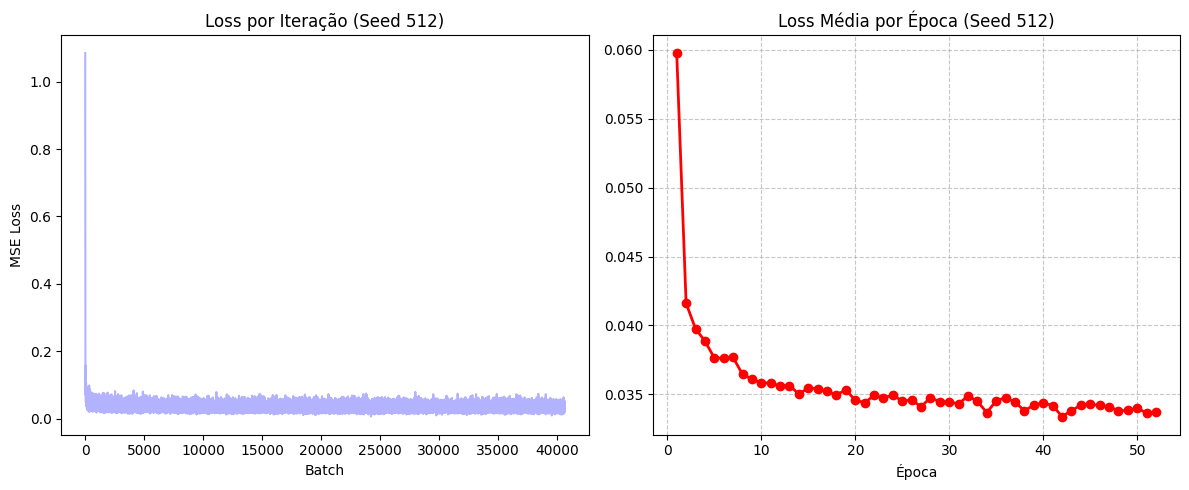

Treino e Gráficos da Seed 512 concluídos.


In [ ]:

seeds_final =  [3, 17, 29, 58, 71, 89, 123, 256, 456, 512]

for seed in seeds_final:
    print(f"\nA TREINAR A SEED {seed}...")
    torch.manual_seed(seed)
    np.random.seed(seed)
 
    model, history = train_final_diffusion_model(train_loader, epochs=100)
    torch.save(model.state_dict(), f"diffusion_optuna_final_full_seed_{seed}.pth")
    plt.figure(figsize=(12, 5))
    

    plt.subplot(1, 2, 1)
    plt.plot(history["iteration_losses"], alpha=0.3, color='blue')
    plt.title(f"Loss por Iteração (Seed {seed})")
    plt.xlabel("Batch")
    plt.ylabel("MSE Loss")
    
  
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(history["epoch_losses"]) + 1), history["epoch_losses"], 
             marker='o', color='red', linewidth=2)
    plt.title(f"Loss Média por Época (Seed {seed})")
    plt.xlabel("Época")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()

    plt.savefig(f"loss_charts_seed_{seed}.png")
    plt.show() 
    
    with open(f"history_diffusion_seed_final_full_{seed}.json", "w") as f:
        json.dump({"epoch_losses": history["epoch_losses"]}, f)
        
    print(f"Treino e Gráficos da Seed {seed} concluídos.")

In [ ]:
seeds_final = [3, 17, 29, 58, 71, 89, 123, 256, 456, 512]
resultados_dir = "." 

for seed in seeds_final:
    print(f"\nAVALIANDO SEED {seed}...")

    metrics_list = evaluate_diffusion_quick_test([seed], resultados_dir, target_samples=5000)
    metrics = metrics_list[0]

    with open(f"history_diffusion_seed_final_full_{seed}.json", "r") as f:
        history_data = json.load(f)
    

    res_json = {
        "seed": seed,
        "metrics": {
            "fid": float(metrics["fid"]),
            "kid": float(metrics["kid"]),
            "kid_std": float(metrics["kid_std"])
        },
        "epoch_loss_history": history_data["epoch_losses"]
    }
    
    with open(f"metrics_diffusion_optuna_final_full_seed_{seed}.json", "w") as f:
        json.dump(res_json, f, indent=2)
        
    print(f"Concluído: Seed {seed} | FID: {res_json['metrics']['fid']:.2f}")

print("\nTODOS OS RESULTADOS FORAM GERADOS!")


AVALIANDO SEED 3...
-> Seed 3: A carregar 5000 imagens reais...


Seed 3 - Gerando 5000 fakes: 100%|██████████| 5000/5000 [44:09<00:00,  1.89it/s]


Concluído: Seed 3 | FID: 84.75

AVALIANDO SEED 17...
-> Seed 17: A carregar 5000 imagens reais...


Seed 17 - Gerando 5000 fakes: 100%|██████████| 5000/5000 [45:01<00:00,  1.85it/s]


Concluído: Seed 17 | FID: 48.89

AVALIANDO SEED 29...
-> Seed 29: A carregar 5000 imagens reais...


...

Concluído: Seed 256 | FID: 60.41

AVALIANDO SEED 456...
-> Seed 456: A carregar 5000 imagens reais...


Seed 456 - Gerando 5000 fakes: 100%|██████████| 5000/5000 [39:49<00:00,  2.09it/s]


Concluído: Seed 456 | FID: 51.77

AVALIANDO SEED 512...
-> Seed 512: A carregar 5000 imagens reais...


Seed 512 - Gerando 5000 fakes: 100%|██████████| 5000/5000 [40:49<00:00,  2.04it/s]


Concluído: Seed 512 | FID: 49.90

TODOS OS RESULTADOS FORAM GERADOS!


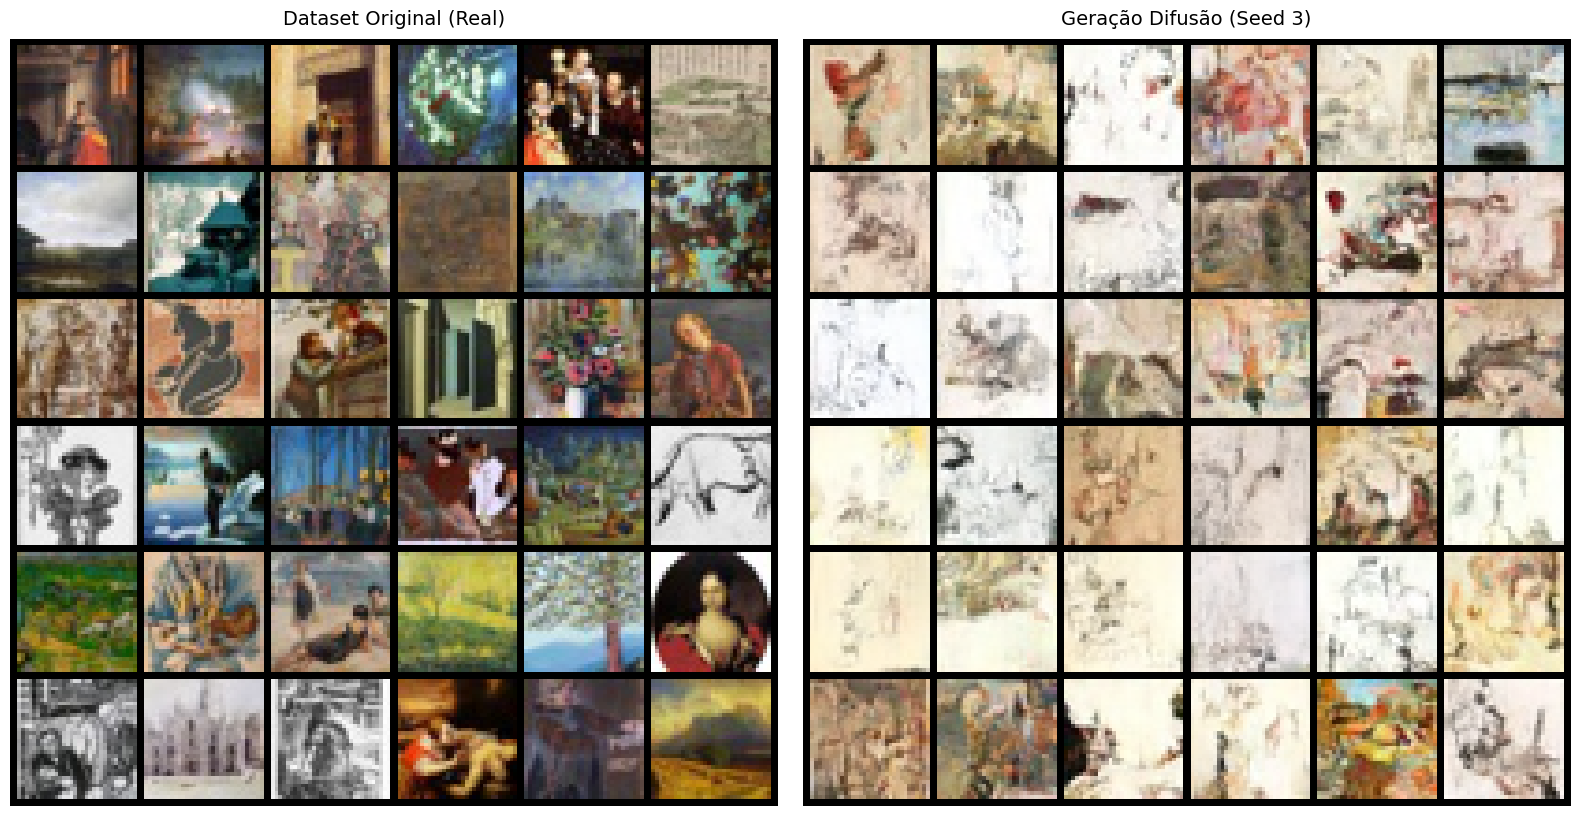

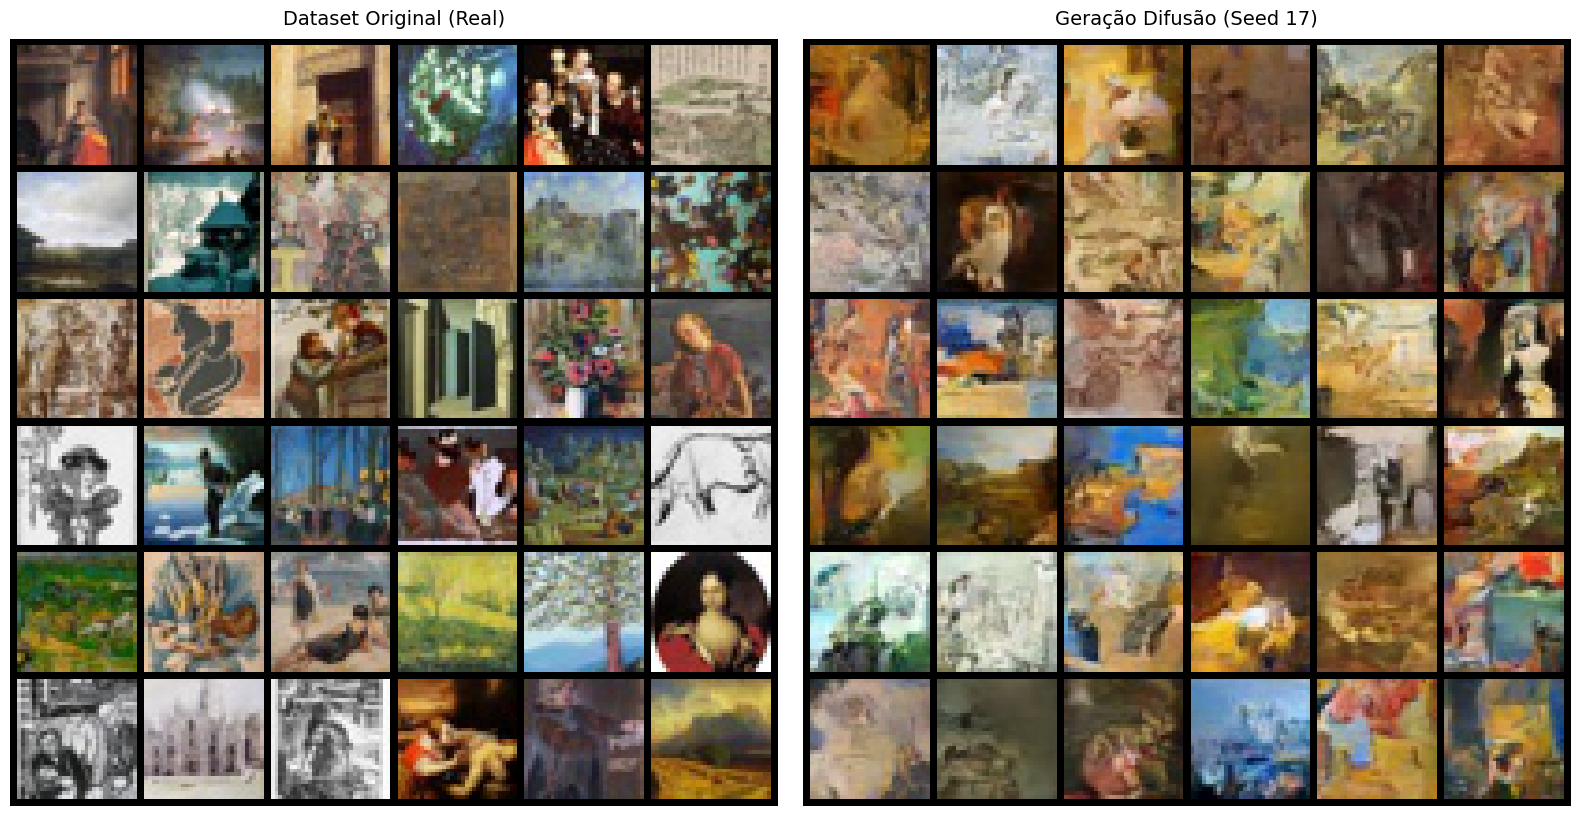

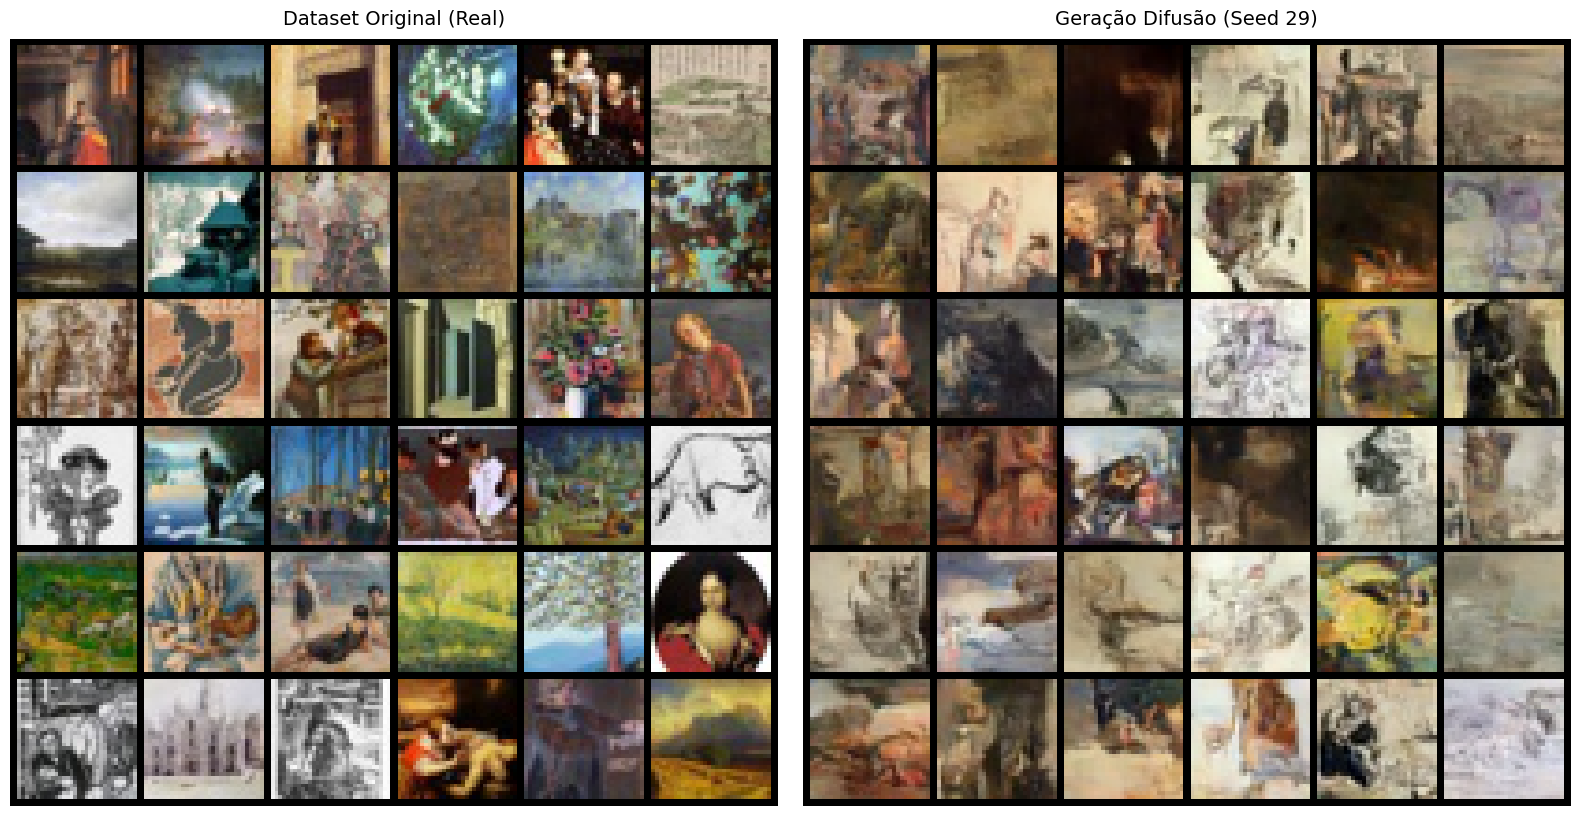

Modelo para a seed 58 não encontrado em: diffusion__optuna__final_seed_58.pth
Modelo para a seed 71 não encontrado em: diffusion__optuna__final_seed_71.pth
Modelo para a seed 89 não encontrado em: diffusion__optuna__final_seed_89.pth
Modelo para a seed 123 não encontrado em: diffusion__optuna__final_seed_123.pth
Modelo para a seed 256 não encontrado em: diffusion__optuna__final_seed_256.pth
Modelo para a seed 456 não encontrado em: diffusion__optuna__final_seed_456.pth
Modelo para a seed 512 não encontrado em: diffusion__optuna__final_seed_512.pth


In [ ]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm

def ver_comparacao_difusao(seed_escolhida, real_images, n_images=36):

    model = SimpleDiffusionUNet(down_channels=(64, 128, 256), time_emb_dim=64).to(DEVICE)
    model_path = f"diffusion__optuna__final_seed_{seed_escolhida}.pth"
    
    try:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()
    except FileNotFoundError:
        print(f"Modelo para a seed {seed_escolhida} não encontrado em: {model_path}")
        return

    noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")

    img = torch.randn((n_images, 3, 32, 32), device=DEVICE)
    for t in tqdm(reversed(range(1000)), total=1000, desc=f"Seed {seed_escolhida} a pintar...", leave=False):
        t_batch = torch.full((n_images,), t, device=DEVICE).long()
        with torch.no_grad():
            noise_pred = model(img, t_batch)
            img = noise_scheduler.step(noise_pred, t, img).prev_sample
            

    img_fake = (img.clamp(-1, 1) * 0.5 + 0.5).cpu()
    grid_fake = make_grid(img_fake, nrow=6, padding=2).permute(1, 2, 0).numpy()
    

    grid_real = make_grid(real_images.cpu(), nrow=6, padding=2, normalize=True).permute(1, 2, 0).numpy()
    

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(grid_real)
    axes[0].set_title("Dataset Original (Real)", fontsize=14, pad=10)
    axes[0].axis('off')
    
    axes[1].imshow(grid_fake)
    axes[1].set_title(f"Geração Difusão (Seed {seed_escolhida})", fontsize=14, pad=10)
    axes[1].axis('off')
    
    plt.tight_layout()

    plt.show()

data_iter = iter(train_loader)
real_batch, *_ = next(data_iter)
real_batch = real_batch[:36].to(DEVICE)

seeds = [3,17,29,58,71,89,123,256,456,512]

for n in seeds:
    ver_comparacao_difusao(n, real_batch)

A pintar...: 100%|██████████| 1000/1000 [00:41<00:00, 23.88it/s]


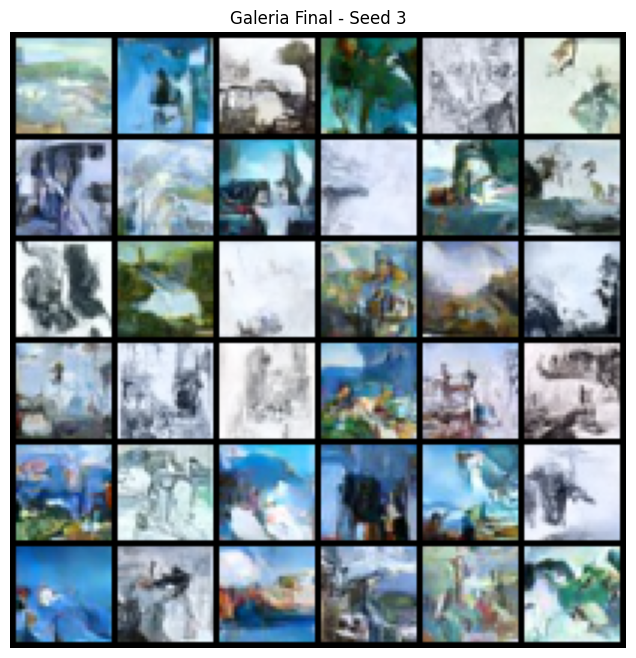

A pintar...: 100%|██████████| 1000/1000 [00:39<00:00, 25.33it/s]


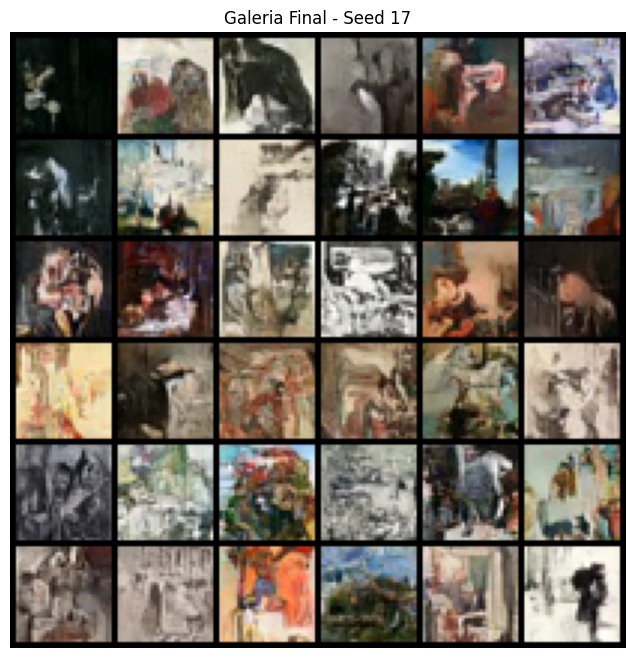

A pintar...: 100%|██████████| 1000/1000 [00:41<00:00, 24.04it/s]


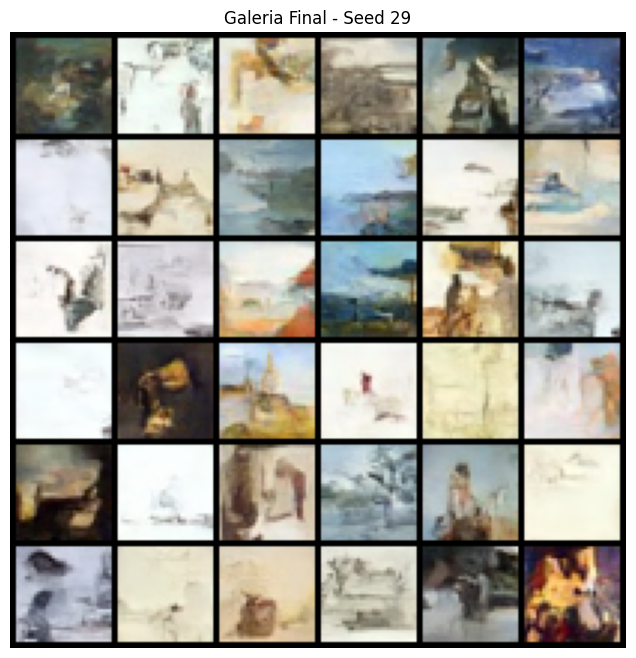

A pintar...: 100%|██████████| 1000/1000 [00:40<00:00, 24.90it/s]


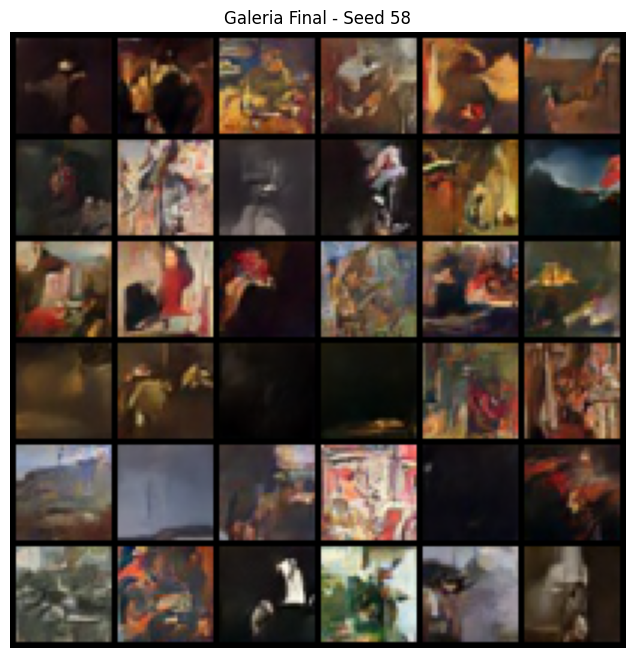

A pintar...: 100%|██████████| 1000/1000 [00:38<00:00, 25.71it/s]


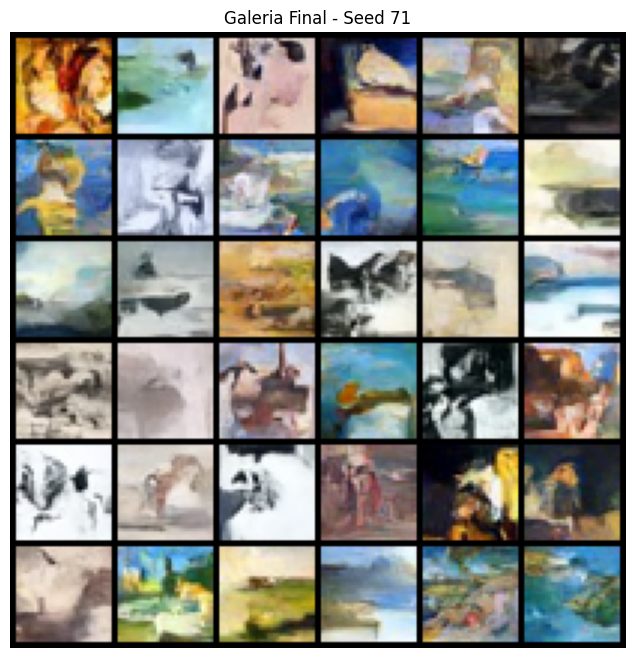

A pintar...: 100%|██████████| 1000/1000 [00:35<00:00, 28.28it/s]


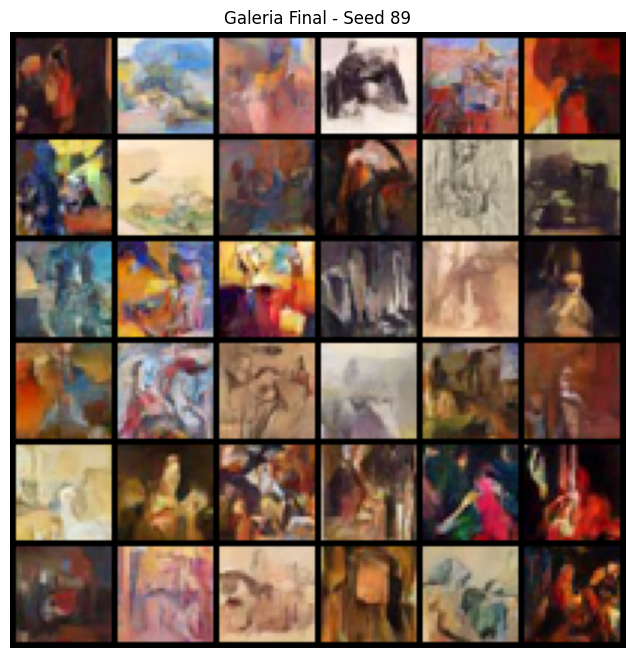

A pintar...: 100%|██████████| 1000/1000 [00:35<00:00, 28.42it/s]


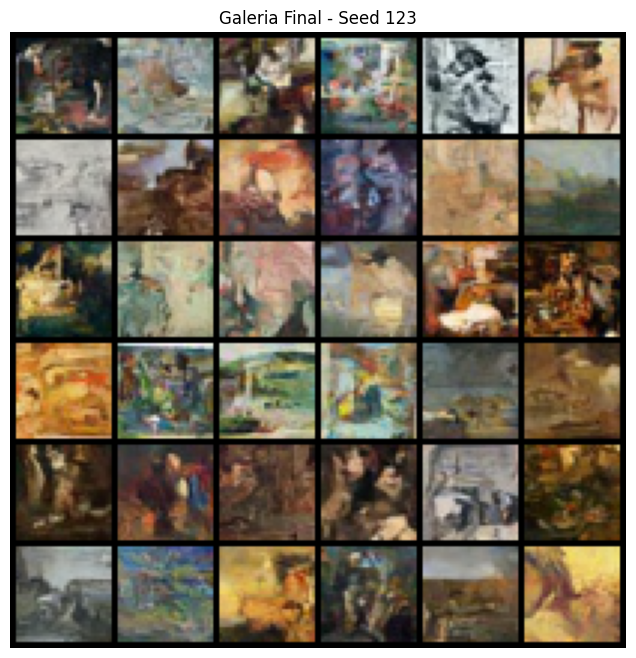

A pintar...: 100%|██████████| 1000/1000 [00:35<00:00, 28.49it/s]


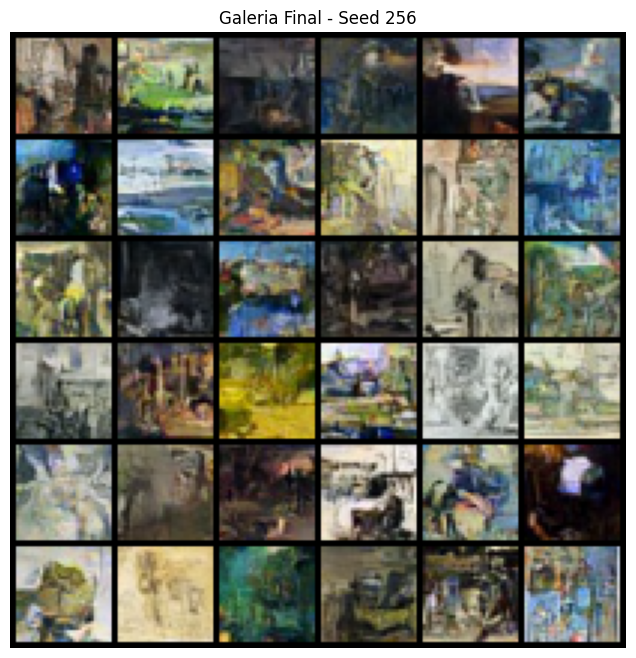

A pintar...: 100%|██████████| 1000/1000 [00:35<00:00, 28.37it/s]


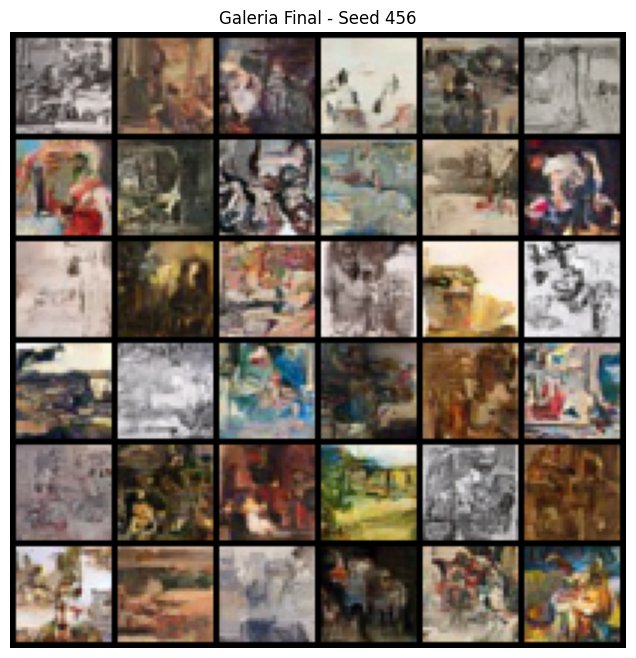

A pintar...: 100%|██████████| 1000/1000 [00:35<00:00, 28.47it/s]


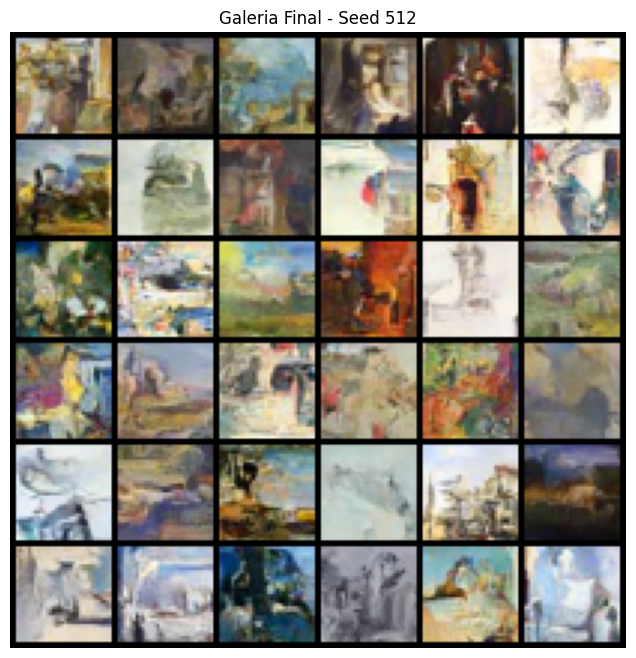

In [ ]:
def ver_amostras_seed(seed_escolhida, n_images=36):
    model = SimpleDiffusionUNet(down_channels=(64, 128, 256), time_emb_dim=64).to(DEVICE)
    model.load_state_dict(torch.load(f"diffusion_optuna_final_full_seed_{seed_escolhida}.pth"))
    model.eval()
    
    noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
    img = torch.randn((n_images, 3, 32, 32), device=DEVICE)
    for t in tqdm(reversed(range(1000)), total=1000, desc="A pintar..."):
        t_batch = torch.full((n_images,), t, device=DEVICE).long()
        with torch.no_grad():
            noise_pred = model(img, t_batch)

    img = (img.clamp(-1, 1) * 0.5 + 0.5).cpu()
    grid = make_grid(img, nrow=6).permute(1, 2, 0).numpy()
    
    plt.figure(figsize=(8, 8))
    plt.imshow(grid)
    plt.axis('off')
    plt.title(f"Galeria Final - Seed {seed_escolhida}")
    plt.show()


for n in [3, 17, 29, 58, 71, 89, 123, 256, 456, 512]:
    ver_amostras_seed(n)

Pintando 8x8 (Seed 17): 100%|██████████| 1000/1000 [00:32<00:00, 30.81it/s]


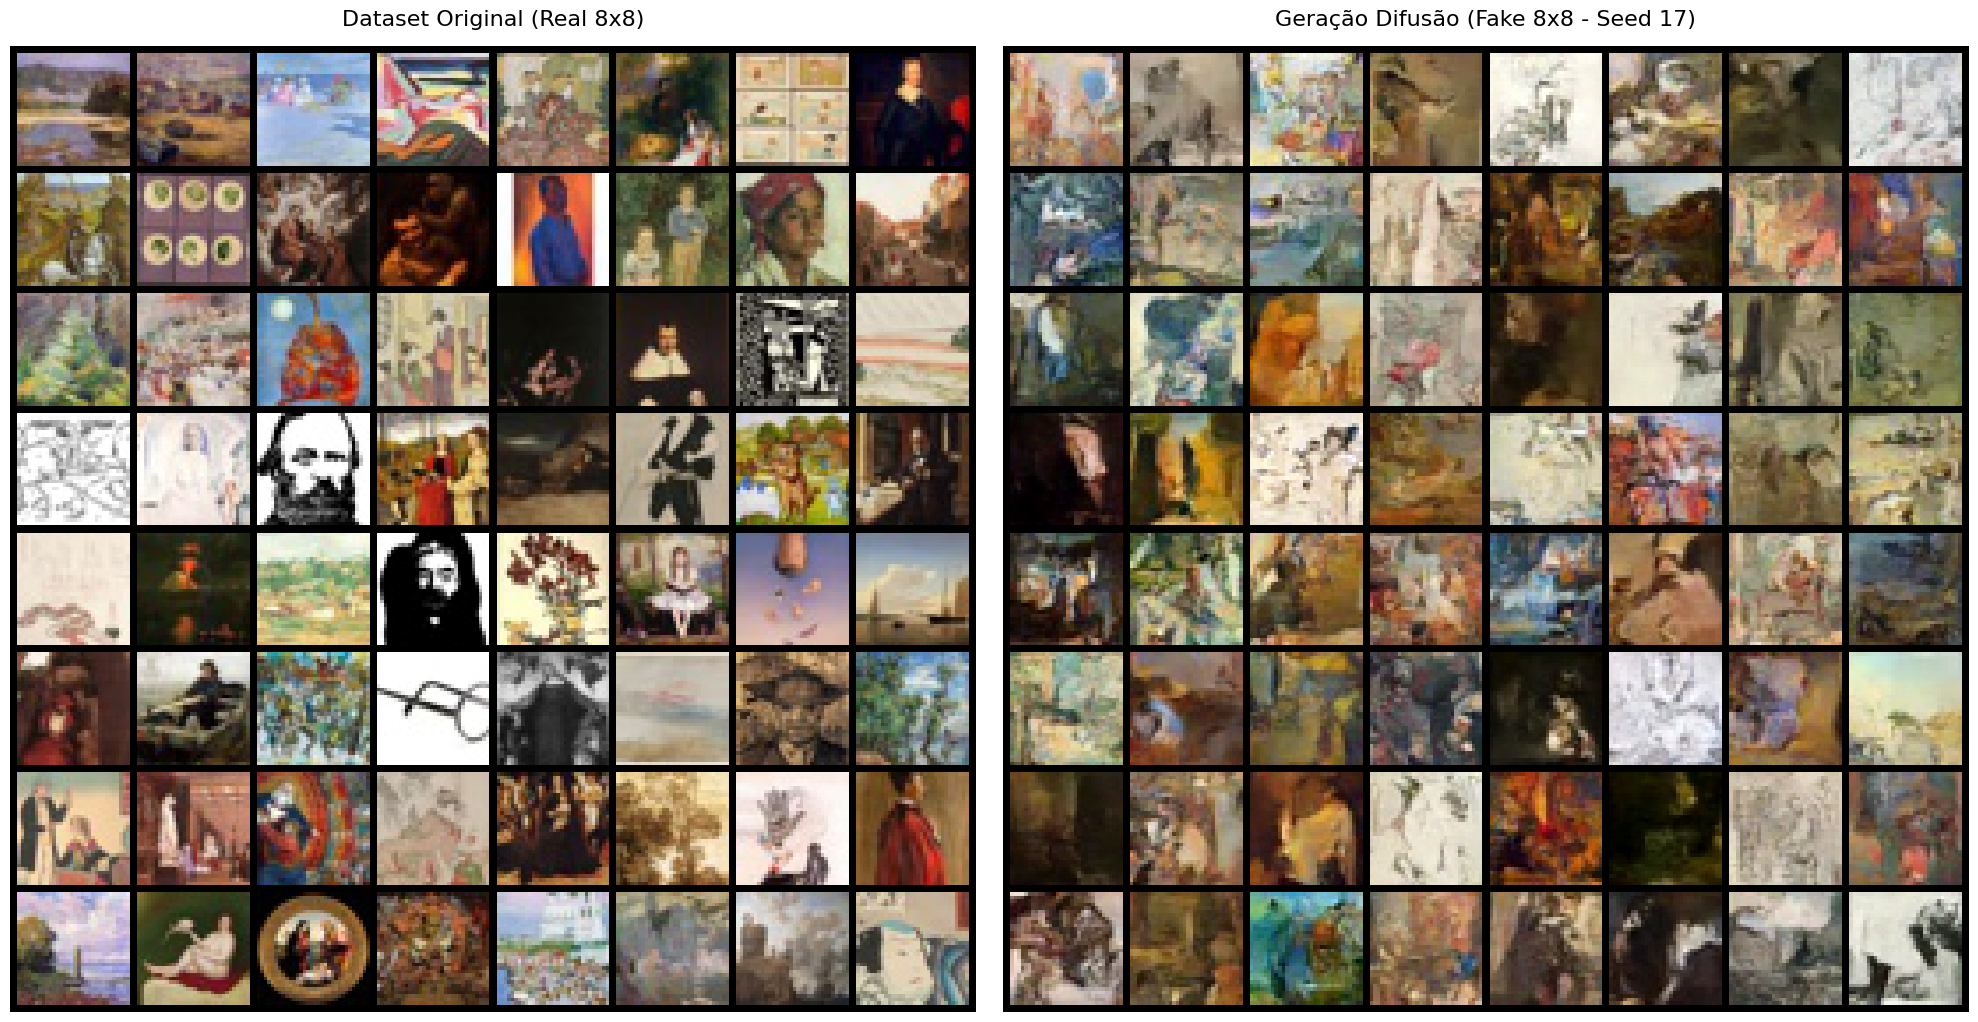

In [ ]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

@torch.no_grad()
def visualizar_comparacao_8x8(seed_escolhida, train_loader, results_path):
    BASE_CH = 64
    TIME_DIM = 64
    n_samples = 64 
    
    model = SimpleDiffusionUNet(
        down_channels=(BASE_CH, BASE_CH*2, BASE_CH*4), 
        time_emb_dim=TIME_DIM
    ).to(DEVICE)
    
    model_file = Path(results_path) / f"diffusion__optuna__final_seed_{seed_escolhida}.pth"
    if not model_file.exists():
        print(f"❌ Ficheiro não encontrado: {model_file}")
        return
    
    model.load_state_dict(torch.load(model_file, map_location=DEVICE))
    model.eval()
    reais_list = []
    for batch in train_loader:
        reais_list.append(batch[0])
        if sum(b.size(0) for b in reais_list) >= n_samples:
            break
    real_batch = torch.cat(reais_list, dim=0)[:n_samples].to(DEVICE)
  
    img_fake = torch.randn((n_samples, 3, 32, 32), device=DEVICE)

    for i in tqdm(reversed(range(0, T)), total=T, desc=f"Pintando 8x8 (Seed {seed_escolhida})"):
        t = torch.full((n_samples,), i, device=DEVICE, dtype=torch.long)
        predicted_noise = model(img_fake, t)
        
        alpha = get_index_from_list(alphas, t, img_fake.shape)
        alpha_cumprod_t = get_index_from_list(alphas_cumprod, t, img_fake.shape)
        beta_t = get_index_from_list(betas, t, img_fake.shape)
        
        noise = torch.randn_like(img_fake) if i > 0 else 0

        img_fake = (1 / torch.sqrt(alpha)) * (img_fake - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise) \
                  + torch.sqrt(beta_t) * noise


    grid_real = make_grid(real_batch.cpu(), nrow=8, normalize=True, padding=2).permute(1, 2, 0).numpy()
    
    img_fake = (img_fake.clamp(-1, 1) + 1) / 2
    grid_fake = make_grid(img_fake.cpu(), nrow=8, padding=2).permute(1, 2, 0).numpy()


    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    axes[0].imshow(grid_real)
    axes[0].set_title("Dataset Original (Real 8x8)", fontsize=16, pad=15)
    axes[0].axis('off')
    
    axes[1].imshow(grid_fake)
    axes[1].set_title(f"Geração Difusão (Fake 8x8 - Seed {seed_escolhida})", fontsize=16, pad=15)
    axes[1].axis('off')
    
    plt.tight_layout()
    
  
    plt.savefig(f"comparacao_final_8x8_seed_{seed_escolhida}.png", dpi=300, bbox_inches='tight')
    plt.show()


caminho_projeto = r"C:\Users\Jose\Mestrado\IAG_TP1"
visualizar_comparacao_8x8(17, train_loader, caminho_projeto)